# Perturbation LOO Evaluation

Evaluates the perturbation model on a held-out cell type in the CRC region.
For each cell type we compute the top-100 pseudobulk logFC genes (CRC vs REF),
perturb REF cells' spatial context accordingly, and measure how well the
predicted expression shift matches the real CRC expression.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
# append scripts
sys.path.append('../../scripts')

import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt
import scvi

import cellina
from cellina import CellinaModel, make_neighbor_perturbation
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features

from perturb_utils import load_crc_slide, load_merfish_brain, split_indices, compute_cf_logfc

plt.rcParams['figure.dpi'] = 75
scvi.settings.seed = 0
print(cellina.__version__)

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

0.7.1


In [2]:
# ── Brain LOO Config ─────────────────────────────────────────────────────────
labels_key       = 'cell_type'
domains_key      = 'major_brain_region'
holdout_celltype = 'glutamatergic neuron'
donor_region     = 'Isocortex'
target_regions   = ['Thalamus', 'Hippocampus']
top_n_perturb    = 100   # genes used to perturb spatial context
top_n            = 100   # genes used to evaluate metrics
min_cells        = 50    # minimum cells per domain per cell type to evaluate
batch_size       = 512
library_size     = 1e4
base_path        = 'results/perturb_loo_brain'
exp_name         = f"{donor_region}_to_{'_'.join(target_regions)}"
save_path        = f"{base_path}/trained/{exp_name}_{holdout_celltype.replace(' ', '_')}"

In [3]:
adata = load_merfish_brain(labels_key=labels_key, domains_key=domains_key)

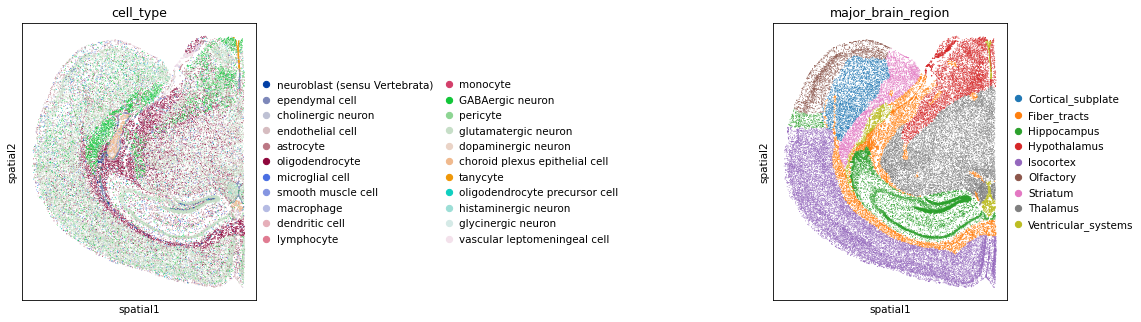

In [4]:
sc.pl.spatial(adata, color=[labels_key, domains_key], spot_size=20, wspace=0.6)

In [5]:
adata.obs[[labels_key, domains_key]].groupby([labels_key, domains_key]).size().sort_values(ascending=False).head(20)

/tmp/ipykernel_3123480/1927349148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[[labels_key, domains_key]].groupby([labels_key, domains_key]).size().sort_values(ascending=False).head(20)


cell_type             major_brain_region
glutamatergic neuron  Isocortex             7730
                      Thalamus              3521
                      Hippocampus           3203
oligodendrocyte       Fiber_tracts          2455
                      Thalamus              1769
glutamatergic neuron  Cortical_subplate     1506
                      Hypothalamus          1349
astrocyte             Isocortex             1295
endothelial cell      Isocortex             1256
astrocyte             Thalamus              1230
GABAergic neuron      Striatum              1142
                      Hypothalamus          1123
astrocyte             Hippocampus           1081
GABAergic neuron      Isocortex             1041
endothelial cell      Thalamus               996
astrocyte             Fiber_tracts           933
glutamatergic neuron  Olfactory              878
oligodendrocyte       Hippocampus            695
glutamatergic neuron  Striatum               688
oligodendrocyte       Hypoth

In [6]:
# Normalize adata.X for compute_spatial_features
sc.pp.normalize_total(adata, target_sum=1e4)

## Three-Region LOO: Isocortex → Thalamus & Hippocampus

`glutamatergic neuron` is held out from **both** Thalamus and Hippocampus simultaneously.
The model sees glu. neurons only in Isocortex, then we test transfer to each target region.
We also compare real vs CF logFC vectors *between* the two target regions to see whether
the model can differentiate their distinct spatial contexts.

In [7]:
import os

all_regions = [donor_region] + target_regions
adata_3r = adata[adata.obs[domains_key].isin(all_regions)].copy()
print(f"Subset: {adata_3r.shape}")
print(adata_3r.obs.groupby([domains_key, labels_key]).size().unstack(fill_value=0))

Subset: (29374, 1120)
cell_type           neuroblast (sensu Vertebrata)  ependymal cell  \
major_brain_region                                                  
Hippocampus                                   186             194   
Isocortex                                       0               0   
Thalamus                                        0              39   

cell_type           endothelial cell  astrocyte  oligodendrocyte  \
major_brain_region                                                 
Hippocampus                      553       1081              695   
Isocortex                       1256       1295              628   
Thalamus                         996       1230             1769   

cell_type           microglial cell  smooth muscle cell  macrophage  \
major_brain_region                                                    
Hippocampus                     275                  38          17   
Isocortex                       529                  82          25   
Thalamu

/tmp/ipykernel_3123480/1913149408.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata_3r.obs.groupby([domains_key, labels_key]).size().unstack(fill_value=0))


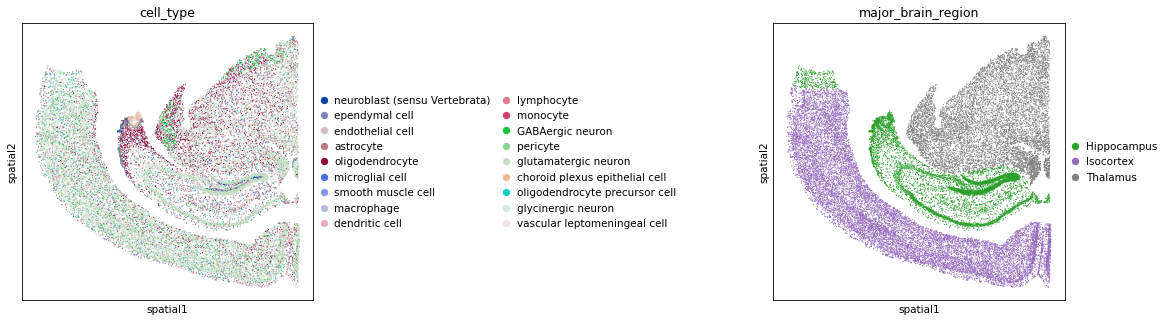

In [8]:
sc.pl.spatial(adata_3r, color=[labels_key, domains_key], spot_size=20, wspace=0.6)

In [9]:
# Spatial graph on the 3-region subset (CCF coords in microns — no pixel conversion)
spatial_neighbors(adata_3r, bandwidth=100, max_neighbours=200, standardize=False)
compute_spatial_features(adata_3r)

# Hold out glutamatergic neurons from BOTH Thalamus AND Hippocampus simultaneously
train_idx, val_idx, test_idx = split_indices(
    adata_3r,
    holdout_celltype=holdout_celltype,
    labels_key=labels_key,
    domains_key=domains_key,
    holdout_domains=tuple(target_regions),  # ('Thalamus', 'Hippocampus')
)
print(f"train={len(train_idx):,}  val={len(val_idx):,}  test (holdout)={len(test_idx):,}")
print(f"Holdout = {holdout_celltype} in {target_regions}: {adata_3r.obs['is_holdout'].sum()} cells")

train=20,385  val=2,265  test (holdout)=6,724
Holdout = glutamatergic neuron in ['Thalamus', 'Hippocampus']: 6724 cells


In [10]:
CellinaModel.setup_anndata(
    adata_3r,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x',
)

model = CellinaModel(
    adata_3r,
    n_latent=20,
    classifier_lambda=1,
    discriminator_lambda=1,
    domain_classifier_lambda=1,
    n_layers=2,
    condition_on_intrinsic=False,
)

model.train(
    max_epochs=100,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_monitor='vae_loss_validation',
    plan_kwargs={'lr': 1e-3, 'weight_decay': 0.0001, 'normalize_losses': True},
    datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
    enable_checkpointing=True,
    batch_size=batch_size,
    devices=[0],
)

os.makedirs(save_path, exist_ok=True)
model.save(save_path, overwrite=True)

INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:186: UserWarning: Category 10 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
INFO: GPU available: True (cuda), used: True
2026-04-09 15:54:12 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-04-09 15:54:12 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-04-09 15:54:12 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-04-09 15:

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 399.860. Signaling Trainer to stop.


<Axes: xlabel='epoch'>

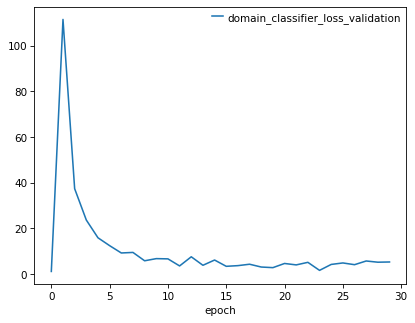

In [11]:
model.history_['domain_classifier_loss_validation'].plot()

In [12]:
pdata = dc.pp.pseudobulk(
    adata=adata_3r,
    sample_col=domains_key,
    groups_col=labels_key,
    mode='sum',
    layer='counts',
)
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

def shared_types(target):
    return [
        ct for ct in pdata.obs[labels_key].unique()
        if ((pdata.obs[domains_key] == donor_region) & (pdata.obs[labels_key] == ct)).any()
        and ((pdata.obs[domains_key] == target) & (pdata.obs[labels_key] == ct)).any()
    ]

def compute_logfc_df(target):
    cts = shared_types(target)
    return pd.concat([
        pd.Series(
            (
                pdata[(pdata.obs[domains_key] == target) & (pdata.obs[labels_key] == ct)].X
                - pdata[(pdata.obs[domains_key] == donor_region) & (pdata.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata.var_names,
            name=ct,
        )
        for ct in cts
    ], axis=1).T

logfc_dfs = {tgt: compute_logfc_df(tgt) for tgt in target_regions}
for tgt, df in logfc_dfs.items():
    print(f"{tgt}: {df.shape}  types: {sorted(df.index.tolist())}")

Thalamus: (18, 1120)  types: ['GABAergic neuron', 'astrocyte', 'choroid plexus epithelial cell', 'dendritic cell', 'endothelial cell', 'ependymal cell', 'glutamatergic neuron', 'glycinergic neuron', 'lymphocyte', 'macrophage', 'microglial cell', 'monocyte', 'neuroblast (sensu Vertebrata)', 'oligodendrocyte', 'oligodendrocyte precursor cell', 'pericyte', 'smooth muscle cell', 'vascular leptomeningeal cell']
Hippocampus: (18, 1120)  types: ['GABAergic neuron', 'astrocyte', 'choroid plexus epithelial cell', 'dendritic cell', 'endothelial cell', 'ependymal cell', 'glutamatergic neuron', 'glycinergic neuron', 'lymphocyte', 'macrophage', 'microglial cell', 'monocyte', 'neuroblast (sensu Vertebrata)', 'oligodendrocyte', 'oligodendrocyte precursor cell', 'pericyte', 'smooth muscle cell', 'vascular leptomeningeal cell']


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [13]:
for tgt in target_regions:
    logfc_series_dict = {}
    for ct in logfc_dfs[tgt].index:
        s = logfc_dfs[tgt].loc[ct]
        top_genes = s.abs().nlargest(top_n_perturb).index.tolist()
        logfc_series_dict[ct] = s[top_genes]

    make_neighbor_perturbation(
        adata_3r,
        perturbations=logfc_series_dict,
        groupby=labels_key,
        obsm_key_out=f'spatial_x_cf_{tgt.lower()}',
        base=np.e,
    )
    print(f"CF features stored: adata_3r.obsm['spatial_x_cf_{tgt.lower()}']")

CF features stored: adata_3r.obsm['spatial_x_cf_thalamus']
CF features stored: adata_3r.obsm['spatial_x_cf_hippocampus']


In [14]:

all_rows = []
logfcs_by_target = {}

for tgt in target_regions:
    cell_types = logfc_dfs[tgt].index.tolist()
    cf_obsm_key = f'spatial_x_cf_{tgt.lower()}'
    logfcs = {}

    for ct in sorted(cell_types):
        ref_mask = (adata_3r.obs[labels_key] == ct) & (adata_3r.obs[domains_key] == donor_region)
        tgt_mask = (adata_3r.obs[labels_key] == ct) & (adata_3r.obs[domains_key] == tgt)

        if ct == holdout_celltype:
            tgt_mask = tgt_mask & adata_3r.obs['is_holdout']

        ref_idx = np.where(ref_mask.values)[0]
        tgt_idx = np.where(tgt_mask.values)[0]

        if len(ref_idx) < min_cells or len(tgt_idx) < min_cells:
            print(f"  skip {ct} in {tgt}: donor={len(ref_idx)}, target={len(tgt_idx)}")
            continue

        print(f"  {tgt} / {ct}: donor={len(ref_idx)}, target={len(tgt_idx)}")

        adata_3r.X = adata_3r.layers['counts'].copy()
        ref_expr = sc.pp.normalize_total(adata_3r[ref_idx], target_sum=library_size, inplace=False)['X']
        ref_expr = ref_expr.toarray() if hasattr(adata_3r[ref_idx].X, 'toarray') else ref_expr

        pert_expr = model.get_perturbed_expression(
            adata=adata_3r, indices=ref_idx,
            spatial_obsm_key=cf_obsm_key,
            batch_size=batch_size, library_size=library_size,
        )
        cf_expr = model.get_normalized_expression(
            indices=tgt_idx, batch_size=batch_size, library_size=library_size,
        )

        stats = compute_cf_logfc(
            ref_expr, pert_expr, cf_expr,
            top_n=top_n,
            gene_names=adata_3r.var_names.tolist(),
        )

        all_rows.append(dict(
            target=tgt, cell_type=ct, holdout=(ct == holdout_celltype),
            n_donor=len(ref_idx), n_target=len(tgt_idx),
            pearson_r=stats['pearson_r'], spearman_r=stats['spearman_r'],
            precision=stats['precision'], rmse=stats['rmse'],
        ))
        logfcs[ct] = stats

    logfcs_by_target[tgt] = logfcs

results_df = pd.DataFrame(all_rows).sort_values(['target', 'pearson_r'], ascending=[True, False]).reset_index(drop=True)
results_df

  Thalamus / GABAergic neuron: donor=1041, target=467


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  Thalamus / astrocyte: donor=1295, target=1230


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  skip choroid plexus epithelial cell in Thalamus: donor=0, target=0
  skip dendritic cell in Thalamus: donor=3, target=0
  Thalamus / endothelial cell: donor=1256, target=996


...

  Hippocampus / pericyte: donor=258, target=116


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  skip smooth muscle cell in Hippocampus: donor=82, target=38
  Hippocampus / vascular leptomeningeal cell: donor=147, target=80


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


,target,cell_type,holdout,n_donor,n_target,pearson_r,spearman_r,precision,rmse
0,Hippocampus,oligodendrocyte precursor cell,False,308,198,0.967929,0.880468,0.80,0.293170
1,Hippocampus,vascular leptomeningeal cell,False,147,80,0.965681,0.800084,0.80,0.270211
2,Hippocampus,pericyte,False,258,116,0.963040,0.809649,0.80,0.239556
3,Hippocampus,microglial cell,False,529,275,0.954393,0.849913,0.77,0.343401
4,Hippocampus,astrocyte,False,1295,1081,0.952866,0.873075,0.68,0.496704
5,Hippocampus,glutamatergic neuron,True,7730,3203,0.950821,0.777342,0.75,0.802718
6,Hippocampus,oligodendrocyte,False,628,695,0.945572,0.896850,0.62,0.571113
7,Hippocampus,endothelial cell,False,1256,553,0.926119,0.760492,0.80,0.308284
8,Hippocampus,GABAergic neuron,False,1041,294,0.796970,0.591743,0.56,0.749436
9,Thalamus,smooth muscle cell,False,82,84,0.992906,0.950507,0.85,0.169048


In [15]:
# target	cell_type	holdout	n_donor	n_target	pearson_r	spearman_r	precision	rmse
# 0	Hippocampus	oligodendrocyte precursor cell	False	308	198	0.986210	0.884752	0.73	0.288361
# 1	Hippocampus	microglial cell	False	529	275	0.984087	0.907711	0.79	0.352249
# 2	Hippocampus	pericyte	False	258	116	0.976271	0.873627	0.69	0.283382
# 3	Hippocampus	endothelial cell	False	1256	553	0.975080	0.769121	0.74	0.273195
# 4	Hippocampus	astrocyte	False	1295	1081	0.970911	0.864746	0.69	0.520878
# 5	Hippocampus	oligodendrocyte	False	628	695	0.954757	0.647777	0.75	0.591368
# 6	Hippocampus	vascular leptomeningeal cell	False	147	80	0.953718	0.857834	0.71	0.410886
# 7	Hippocampus	glutamatergic neuron	True	7730	3203	0.914149	0.848593	0.60	0.931742
# 8	Hippocampus	GABAergic neuron	False	1041	294	0.876373	0.796076	0.57	0.571250
# 9	Thalamus	vascular leptomeningeal cell	False	147	68	0.993187	0.954803	0.87	0.176418
# 10	Thalamus	oligodendrocyte precursor cell	False	308	269	0.992090	0.958416	0.88	0.382310
# 11	Thalamus	oligodendrocyte	False	628	1769	0.991034	0.951755	0.90	0.294141
# 12	Thalamus	endothelial cell	False	1256	996	0.990296	0.970753	0.83	0.367669
# 13	Thalamus	microglial cell	False	529	275	0.988299	0.957420	0.81	0.440239
# 14	Thalamus	astrocyte	False	1295	1230	0.988102	0.951227	0.77	0.556547
# 15	Thalamus	smooth muscle cell	False	82	84	0.986242	0.937246	0.77	0.247030
# 16	Thalamus	pericyte	False	258	217	0.983647	0.940738	0.75	0.357924
# 17	Thalamus	glutamatergic neuron	True	7730	3521	0.949289	0.863102	0.55	1.317171
# 18	Thalamus	GABAergic neuron	False	1041	467	0.915813	0.871851	0.56	1.049374

In [16]:
results_df.groupby(['target', 'holdout'])[['pearson_r', 'spearman_r', 'precision', 'rmse']].mean()

pearson_r  spearman_r  precision      rmse
target      holdout                                            
Hippocampus False     0.934071    0.807784   0.728750  0.408984
            True      0.950821    0.777342   0.750000  0.802718
Thalamus    False     0.983622    0.917181   0.811111  0.469810
            True      0.957879    0.872991   0.630000  1.195592

In [17]:
# 	pearson_r	spearman_r	precision	rmse
# target	holdout				
# Hippocampus	False	0.959676	0.825206	0.708750	0.411446
# True	0.914149	0.848593	0.600000	0.931742
# Thalamus	False	0.980968	0.943801	0.793333	0.430184
# True	0.949289	0.863102	0.550000	1.317171

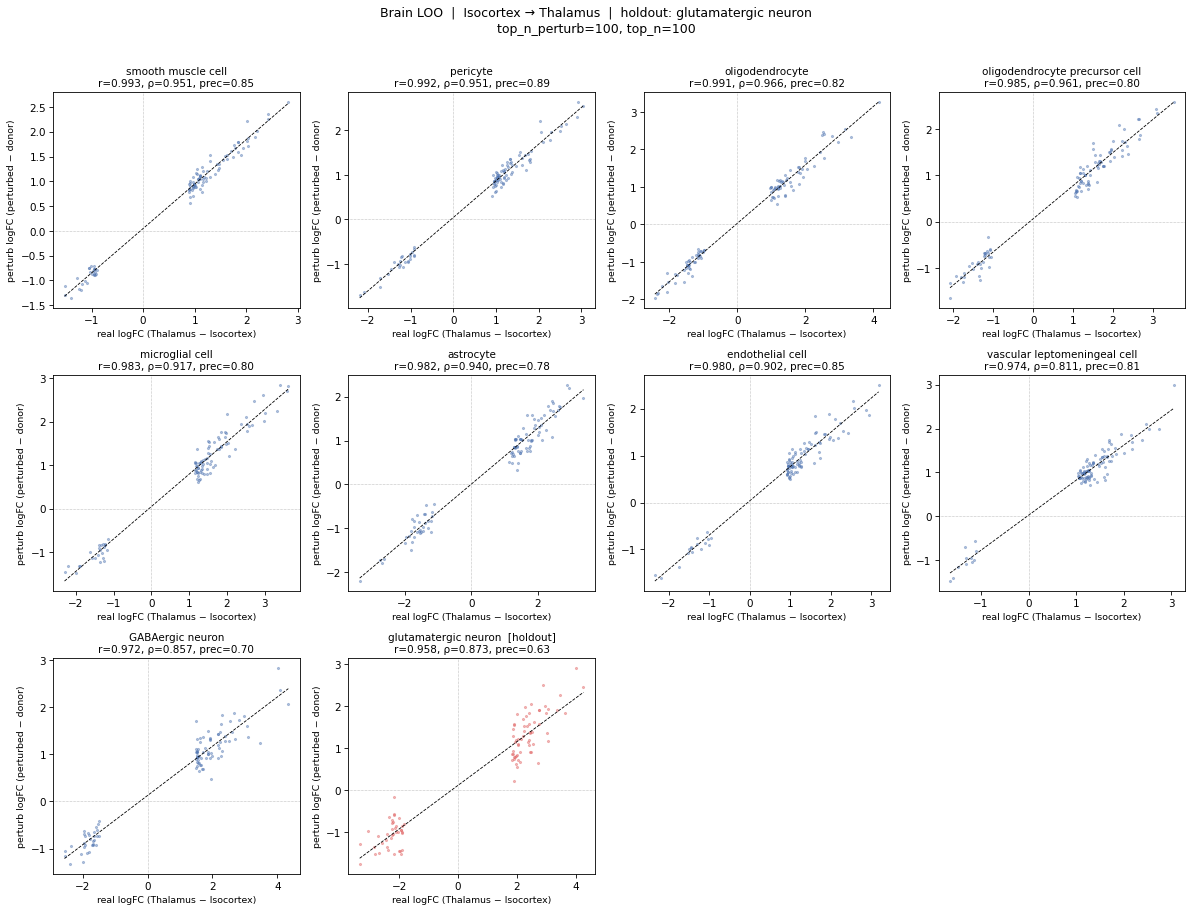

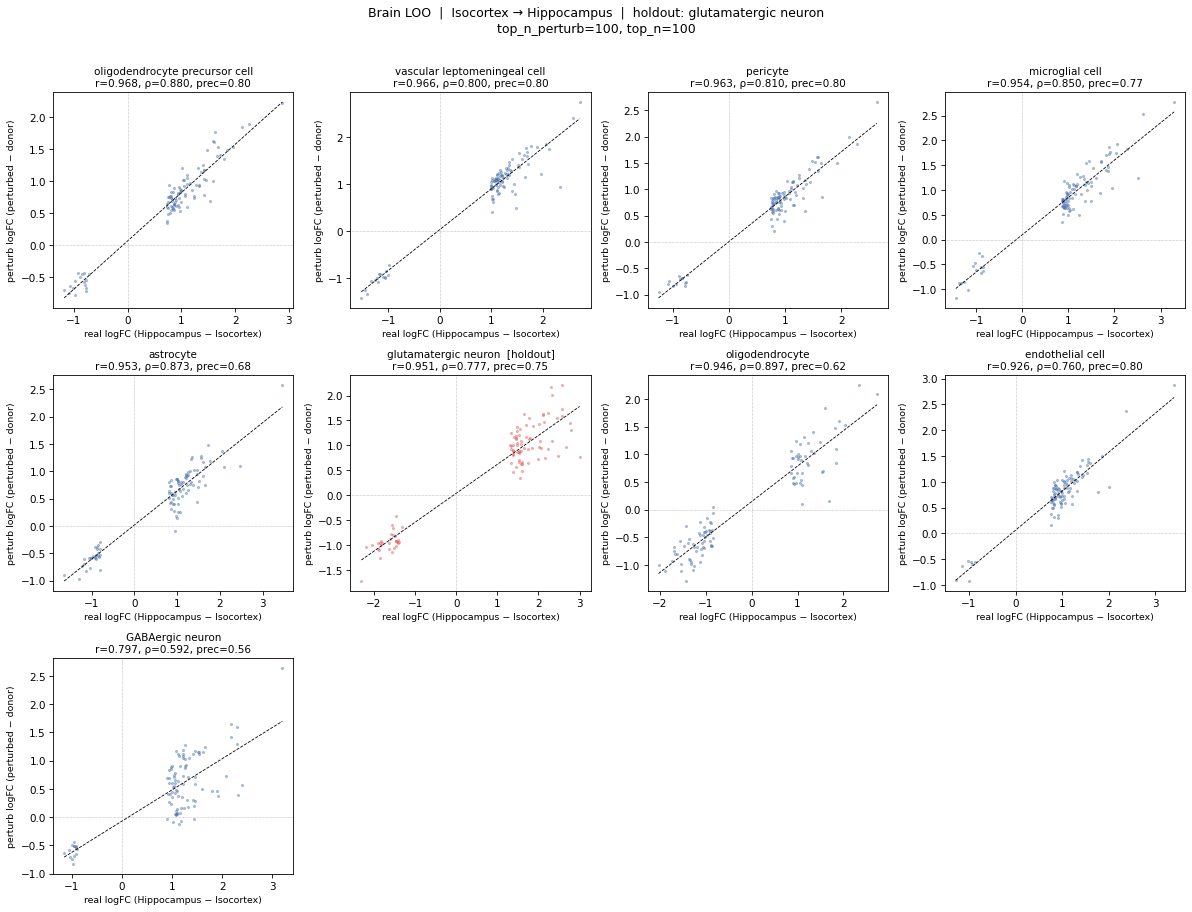

In [18]:
for tgt in target_regions:
    logfcs = logfcs_by_target[tgt]
    sub_df = results_df[results_df['target'] == tgt].reset_index(drop=True)

    ncols = 4
    nrows = (len(sub_df) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, row in sub_df.iterrows():
        ct = row['cell_type']
        ax = axes[i]
        real = logfcs[ct]['real_logfc']
        pred = logfcs[ct]['pred_logfc']
        mask = logfcs[ct]['top_n_mask']
        if mask is not None:
            real, pred = real[mask], pred[mask]

        color = '#e05c5c' if row['holdout'] else '#4C72B0'
        ax.scatter(real, pred, s=4, alpha=0.4, color=color)
        m, b = np.polyfit(real, pred, 1)
        x_lo, x_hi = real.min(), real.max()
        ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], 'k--', lw=0.8)
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        ax.axvline(0, color='grey', lw=0.5, ls=':')

        title = f"{ct}{'  [holdout]' if row['holdout'] else ''}"
        ax.set_title(
            f"{title}\nr={row['pearson_r']:.3f}, ρ={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
            fontsize=10,
        )
        ax.set_xlabel(f'real logFC ({tgt} − {donor_region})', fontsize=9)
        ax.set_ylabel('perturb logFC (perturbed − donor)', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f"Brain LOO  |  {donor_region} → {tgt}  |  holdout: {holdout_celltype}\n"
        f"top_n_perturb={top_n_perturb}, top_n={top_n}",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

Cross-region logFC similarity (Thalamus vs Hippocampus):


,cell_type,holdout,real_pearson_r,real_spearman_r,cf_pearson_r,cf_spearman_r
0,vascular leptomeningeal cell,False,0.907708,0.913346,0.952731,0.949901
1,oligodendrocyte precursor cell,False,0.791240,0.778226,0.830928,0.822391
2,oligodendrocyte,False,0.739145,0.745307,0.741734,0.758436
3,pericyte,False,0.684369,0.705682,0.778240,0.798994
4,glutamatergic neuron,True,0.665797,0.661449,0.687565,0.685889
5,microglial cell,False,0.622038,0.641696,0.687448,0.701064
6,endothelial cell,False,0.589004,0.639109,0.634737,0.675437
7,astrocyte,False,0.562057,0.593883,0.621950,0.659947
8,GABAergic neuron,False,0.551004,0.574420,0.638544,0.614139


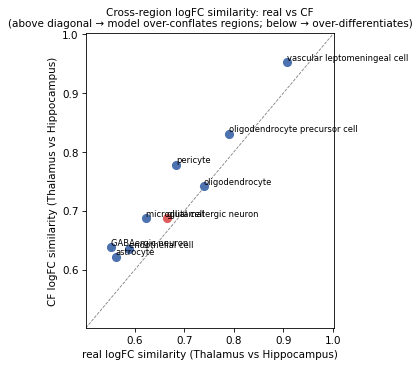

In [19]:
from scipy.stats import pearsonr, spearmanr

# Cell types evaluated in both target regions
common_cts = sorted(
    set(logfcs_by_target[target_regions[0]].keys())
    & set(logfcs_by_target[target_regions[1]].keys())
)

cross_rows = []
for ct in common_cts:
    s0 = logfcs_by_target[target_regions[0]][ct]   # Thalamus
    s1 = logfcs_by_target[target_regions[1]][ct]   # Hippocampus

    # Full-gene logFC vectors (not filtered by top_n_mask)
    real_r,   _ = pearsonr(s0['real_logfc'], s1['real_logfc'])
    real_rho, _ = spearmanr(s0['real_logfc'], s1['real_logfc'])
    cf_r,     _ = pearsonr(s0['pred_logfc'], s1['pred_logfc'])
    cf_rho,   _ = spearmanr(s0['pred_logfc'], s1['pred_logfc'])

    cross_rows.append(dict(
        cell_type=ct, holdout=(ct == holdout_celltype),
        real_pearson_r=real_r, real_spearman_r=real_rho,
        cf_pearson_r=cf_r,     cf_spearman_r=cf_rho,
    ))

cross_df = pd.DataFrame(cross_rows).sort_values('real_pearson_r', ascending=False).reset_index(drop=True)
print(f"Cross-region logFC similarity ({target_regions[0]} vs {target_regions[1]}):")
display(cross_df)

# Scatter: real-real vs CF-CF similarity per cell type
fig, ax = plt.subplots(figsize=(5, 5))
for _, row in cross_df.iterrows():
    color = '#e05c5c' if row['holdout'] else '#4C72B0'
    ax.scatter(row['real_pearson_r'], row['cf_pearson_r'], s=60, color=color, zorder=3)
    ax.annotate(row['cell_type'], (row['real_pearson_r'], row['cf_pearson_r']),
                fontsize=8, ha='left', va='bottom')

lim = [min(cross_df[['real_pearson_r', 'cf_pearson_r']].min()) - 0.05,
       max(cross_df[['real_pearson_r', 'cf_pearson_r']].max()) + 0.05]
ax.plot(lim, lim, color='grey', ls='--', lw=0.8)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel(f'real logFC similarity ({target_regions[0]} vs {target_regions[1]})', fontsize=10)
ax.set_ylabel(f'CF logFC similarity ({target_regions[0]} vs {target_regions[1]})', fontsize=10)
ax.set_title(
    'Cross-region logFC similarity: real vs CF\n'
    '(above diagonal → model over-conflates regions; below → over-differentiates)',
    fontsize=10,
)
plt.tight_layout()
plt.show()

In [20]:
os.makedirs(base_path, exist_ok=True)
results_df.to_csv(f"{base_path}/brain_loo_{exp_name}_metrics.csv", index=False)
cross_df.to_csv(f"{base_path}/brain_loo_{exp_name}_crossregion.csv", index=False)
print(f"Saved metrics:     {base_path}/brain_loo_{exp_name}_metrics.csv")
print(f"Saved cross-region:{base_path}/brain_loo_{exp_name}_crossregion.csv")

Saved metrics:     results/perturb_loo_brain/brain_loo_Isocortex_to_Thalamus_Hippocampus_metrics.csv
Saved cross-region:results/perturb_loo_brain/brain_loo_Isocortex_to_Thalamus_Hippocampus_crossregion.csv
